In [2]:
# Baseline model for batching monitoring example

In [27]:
import requests 
import datetime 
import pandas as pd

from evidently import ColumnMapping
from evidently.report import Report
from evidently.metrics import ColumnDriftMetric, DatasetDriftMetric, DatasetMissingValuesMetric


from joblib import load, dump 
from tqdm import tqdm 

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [2]:
import evidently
print(evidently.__version__)

0.3.0


In [3]:
files=[("green_tripdata_2022-02.parquet","./data"),('green_tripdata_2022-01.parquet','./data')]

print("Download files:")
for file, path in files:
    url=f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file}"
    resp=requests.get(url, stream=True)
    save_path=f"{path}/{file}"
    with open(save_path, "wb") as handle:
        for data in tqdm(resp.iter_content(),
                         desc=f"{file}",
                         postfix=f"save to {save_path}",
                         total=int(resp.headers["Content-Length"])):
            handle.write(data)

Download files:


green_tripdata_2022-02.parquet: 100%|█| 1428262/1428262 [00:09<00:00, 157038.1
green_tripdata_2022-01.parquet: 100%|█| 1254291/1254291 [00:08<00:00, 140960.5


In [4]:
jan_data=pd.read_parquet('data/green_tripdata_2022-01.parquet')

In [5]:
jan_data.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,62495.000000,62495,62495,56200.000000,62495.000000,62495.000000,56200.000000,62495.000000,62495.000000,62495.00000,62495.000000,62495.000000,62495.000000,62495.000000,62495.000000,56200.000000,56200.000000,56200.000000
mean,1.849508,2022-01-16 14:18:36.026354,2022-01-16 14:37:37.189551,1.198719,97.615041,135.969902,1.258399,77.758632,13.914000,0.34756,0.426322,1.666540,0.208182,0.297312,17.490532,1.403594,1.040925,0.706628
min,1.000000,2009-01-01 00:34:01,2009-01-01 17:05:20,1.000000,1.000000,1.000000,0.000000,0.000000,-65.000000,-4.50000,-0.500000,-0.860000,-6.550000,-0.300000,-71.850000,1.000000,1.000000,0.000000
25%,2.000000,2022-01-08 23:41:50,2022-01-08 23:55:28.500000,1.000000,55.000000,74.000000,1.000000,1.080000,7.000000,0.00000,0.500000,0.000000,0.000000,0.300000,9.360000,1.000000,1.000000,0.000000
50%,2.000000,2022-01-16 15:59:42,2022-01-16 16:17:00,1.000000,75.000000,137.000000,1.000000,1.900000,10.500000,0.00000,0.500000,1.000000,0.000000,0.300000,13.860000,1.000000,1.000000,0.000000
75%,2.000000,2022-01-24 09:16:50,2022-01-24 09:37:28,1.000000,130.000000,215.000000,1.000000,3.500000,17.000000,0.50000,0.500000,2.610000,0.000000,0.300000,21.050000,2.000000,1.000000,2.750000
max,2.000000,2022-01-31 23:57:37,2022-02-01 21:01:54,5.000000,265.000000,265.000000,8.000000,224481.380000,604.500000,4.50000,0.500000,76.770000,44.750000,0.300000,605.300000,5.000000,2.000000,2.750000
std,0.357556,NaN,NaN,0.862313,62.987311,77.590956,0.877743,2909.354163,12.088819,0.65781,0.181381,2.484928,1.257659,0.037201,13.623416,0.516316,0.198119,1.201632


In [6]:
jan_data.shape

(62495, 20)

In [7]:
#create the target 

jan_data['duration_min']=jan_data.lpep_dropoff_datetime - jan_data.lpep_pickup_datetime
jan_data.duration_min = jan_data.duration_min.apply(lambda td : float(td.total_seconds())/60)

In [8]:
#Filter out the outlier

jan_data= jan_data[(jan_data.duration_min >= 0 ) & (jan_data.duration_min <= 60 )]
jan_data= jan_data[(jan_data.passenger_count > 0 ) & (jan_data.passenger_count <= 8)]

<Axes: >

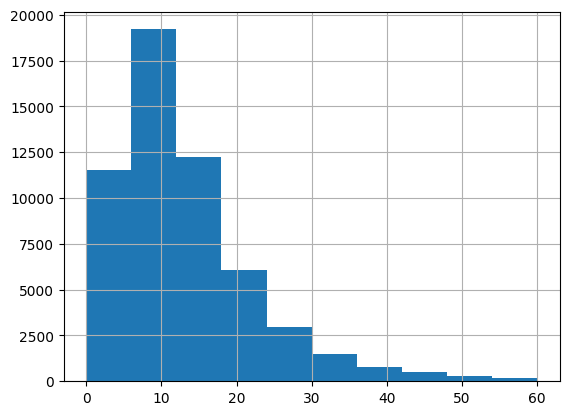

In [9]:
jan_data.duration_min.hist()

In [10]:
# data labeling 

target= "duration_min"
num_features = ["passenger_count","trip_distance","fare_amount","total_amount"]
cat_features = ["PULocationID", "DOLocationID"]

In [11]:
jan_data.shape

(55211, 21)

In [12]:
train_data=jan_data[:30000]
val_data=jan_data[30000:]

In [13]:
model= LinearRegression()

In [14]:
model.fit(train_data[num_features + cat_features],train_data[target])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
train_preds = model.predict(train_data[num_features + cat_features])
train_data['prediction'] = train_preds

In [16]:
val_preds=model.predict(val_data[num_features + cat_features])
val_data['prediction']=val_preds

In [17]:
print(mean_absolute_error(train_data.duration_min, train_data.prediction))
print(mean_absolute_error(val_data.duration_min, val_data.prediction))

3.804665373785062
4.142064073688447


In [18]:
# Dump model and reference data 

In [19]:
with open("models/lin_reg.bin","wb") as f_out:
    dump(model, f_out)

In [20]:
val_data.to_parquet('data/reference.parquet')

In [21]:
# Evidently Report

In [23]:
column_mapping = ColumnMapping(
        target=None,
        prediction='prediction',
        numerical_features=num_features,
        categorical_features=cat_features
    
)

In [28]:
report=Report(metrics=[
    ColumnDriftMetric(column_name='prediction'),
    DatasetDriftMetric(),
    DatasetMissingValuesMetric()])

In [29]:
report.run(reference_data=train_data, current_data=val_data, column_mapping=column_mapping)

In [30]:
report.show(mode='inline')

In [31]:

result = report.as_dict()

In [32]:
result

{'metrics': [{'metric': 'ColumnDriftMetric',
   'result': {'column_name': 'prediction',
    'column_type': 'num',
    'stattest_name': 'Wasserstein distance (normed)',
    'stattest_threshold': 0.1,
    'drift_score': 0.03049316466166379,
    'drift_detected': False,
    'current': {'small_distribution': {'x': [-36.73636669418381,
       -15.174383681788164,
       6.387599330607479,
       27.949582343003122,
       49.511565355398766,
       71.07354836779442,
       92.63553138019006,
       114.1975143925857,
       135.75949740498135,
       157.321480417377,
       178.88346342977263],
      'y': [9.197953980856964e-06,
       0.00110927325009135,
       0.04410786851980149,
       0.0010780002065564362,
       4.598976990428481e-05,
       1.6556317165542536e-05,
       1.8395907961713929e-06,
       3.6791815923427858e-06,
       1.8395907961713929e-06,
       3.6791815923427858e-06]}},
    'reference': {'small_distribution': {'x': [-28.669071967171647,
       -9.81048482283448

In [33]:
result['metrics'][0]['result']['drift_score']

0.03049316466166379

In [34]:
result['metrics'][1]['result']

{'drift_share': 0.5,
 'number_of_columns': 7,
 'number_of_drifted_columns': 0,
 'share_of_drifted_columns': 0.0,
 'dataset_drift': False}

In [37]:
result['metrics'][2]['result']['current']

{'different_missing_values': {'': 0, -inf: 0, None: 25211, inf: 0},
 'number_of_different_missing_values': 1,
 'different_missing_values_by_column': {'VendorID': {'': 0,
   -inf: 0,
   None: 0,
   inf: 0},
  'lpep_pickup_datetime': {'': 0, -inf: 0, None: 0, inf: 0},
  'lpep_dropoff_datetime': {'': 0, -inf: 0, None: 0, inf: 0},
  'store_and_fwd_flag': {'': 0, -inf: 0, None: 0, inf: 0},
  'RatecodeID': {'': 0, -inf: 0, None: 0, inf: 0},
  'PULocationID': {'': 0, -inf: 0, None: 0, inf: 0},
  'DOLocationID': {'': 0, -inf: 0, None: 0, inf: 0},
  'passenger_count': {'': 0, -inf: 0, None: 0, inf: 0},
  'trip_distance': {'': 0, -inf: 0, None: 0, inf: 0},
  'fare_amount': {'': 0, -inf: 0, None: 0, inf: 0},
  'extra': {'': 0, -inf: 0, None: 0, inf: 0},
  'mta_tax': {'': 0, -inf: 0, None: 0, inf: 0},
  'tip_amount': {'': 0, -inf: 0, None: 0, inf: 0},
  'tolls_amount': {'': 0, -inf: 0, None: 0, inf: 0},
  'ehail_fee': {'': 0, -inf: 0, None: 25211, inf: 0},
  'improvement_surcharge': {'': 0, -inf: 

In [39]:
result['metrics'][2]['result']['current']['share_of_missing_values']

0.045454545454545456